#🛠️ Preparação dos dados

In [2]:
from google.colab import files
uploaded = files.upload()

Saving TelecomX.csv to TelecomX.csv


In [3]:
import pandas as pd

df = pd.read_csv("TelecomX.csv")
print(df.head())

   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet.InternetService  ... 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

tabela = pd.read_csv('TelecomX.csv')
print(tabela.shape)
tabela.head()

(7043, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [5]:
# vendo as colunas que tem
for i, col in enumerate(tabela.columns):
    print(f"{i}. {col}")

0. customerID
1. Churn
2. customer.gender
3. customer.SeniorCitizen
4. customer.Partner
5. customer.Dependents
6. customer.tenure
7. phone.PhoneService
8. phone.MultipleLines
9. internet.InternetService
10. internet.OnlineSecurity
11. internet.OnlineBackup
12. internet.DeviceProtection
13. internet.TechSupport
14. internet.StreamingTV
15. internet.StreamingMovies
16. account.Contract
17. account.PaperlessBilling
18. account.PaymentMethod
19. account.Charges.Monthly
20. account.Charges.Total


In [6]:
# tirando o customerID porque é só um identificador, nao ajuda no modelo
tabela.drop(columns=['customerID'], inplace=True)
print(tabela.shape)

(7043, 20)


In [7]:
# vendo se sobrou algum nulo
print(tabela.isnull().sum()[tabela.isnull().sum() > 0])

# preenchendo nulo de charges total com a mediana
if tabela['account.Charges.Total'].isnull().sum() > 0:
    mediana = tabela['account.Charges.Total'].median()
    tabela['account.Charges.Total'].fillna(mediana, inplace=True)
    print(f"preenchi com mediana: {mediana:.2f}")

print(f"nulos restantes: {tabela.isnull().sum().sum()}")

account.Charges.Total    11
dtype: int64
preenchi com mediana: 1397.47
nulos restantes: 0


In [8]:
# transformando churn em 0 e 1
print("antes:", tabela['Churn'].unique())

tabela['Churn'] = tabela['Churn'].map({'Yes': 1, 'No': 0})

print("depois:", tabela['Churn'].unique())
tabela['Churn'].value_counts()

antes: ['No' 'Yes']
depois: [0 1]


,count
Churn,
0,5174
1,1869


ficaram: 73.5%
sairam:  26.5%


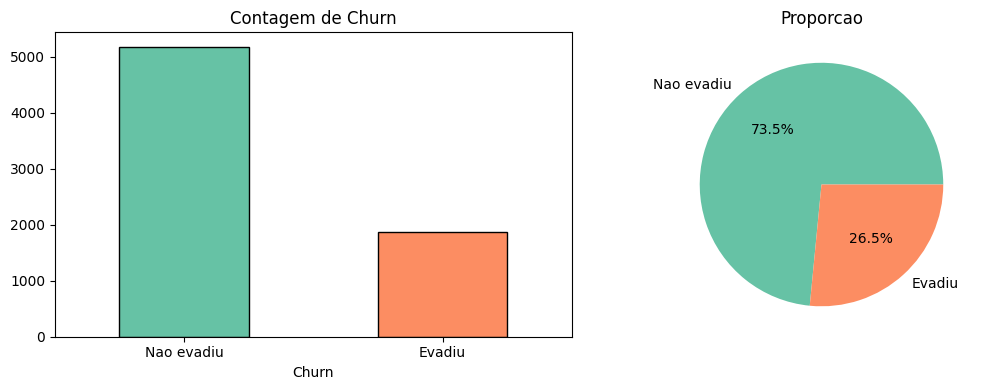

In [9]:
# vendo a proporcao de evasao
prop = tabela['Churn'].value_counts(normalize=True) * 100

print(f"ficaram: {prop[0]:.1f}%")
print(f"sairam:  {prop[1]:.1f}%")
# ta desbalanceado, vou usar class_weight nos modelos

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

tabela['Churn'].value_counts().plot.bar(ax=axs[0], color=['#66c2a5', '#fc8d62'], edgecolor='black')
axs[0].set_title('Contagem de Churn')
axs[0].set_xticklabels(['Nao evadiu', 'Evadiu'], rotation=0)

tabela['Churn'].value_counts().plot.pie(ax=axs[1], autopct='%1.1f%%',
                                         colors=['#66c2a5', '#fc8d62'],
                                         labels=['Nao evadiu', 'Evadiu'])
axs[1].set_ylabel('')
axs[1].set_title('Proporcao')

plt.tight_layout()
plt.show()

In [10]:
# one hot encoding nas colunas categoricas
cols_cat = tabela.select_dtypes(include='object').columns.tolist()

print(f"{len(cols_cat)} colunas categoricas:")
for col in cols_cat:
    print(f"  {col}: {tabela[col].unique()[:5]}")

tabela_encoded = pd.get_dummies(tabela, columns=cols_cat, drop_first=True, dtype=int)

print(f"\nantes: {tabela.shape} -> depois: {tabela_encoded.shape}")
tabela_encoded.head()

15 colunas categoricas:
  customer.gender: ['Female' 'Male']
  customer.Partner: ['Yes' 'No']
  customer.Dependents: ['Yes' 'No']
  phone.PhoneService: ['Yes' 'No']
  phone.MultipleLines: ['No' 'Yes' 'No phone service']
  internet.InternetService: ['DSL' 'Fiber optic' 'No']
  internet.OnlineSecurity: ['No' 'Yes' 'No internet service']
  internet.OnlineBackup: ['Yes' 'No' 'No internet service']
  internet.DeviceProtection: ['No' 'Yes' 'No internet service']
  internet.TechSupport: ['Yes' 'No' 'No internet service']
  internet.StreamingTV: ['Yes' 'No' 'No internet service']
  internet.StreamingMovies: ['No' 'Yes' 'No internet service']
  account.Contract: ['One year' 'Month-to-month' 'Two year']
  account.PaperlessBilling: ['Yes' 'No']
  account.PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

antes: (7043, 20) -> depois: (7043, 31)


,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,0,1,1,1,0,...,0,1,0,0,1,0,1,0,0,1
1,0,0,9,59.9,542.40,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
2,1,0,4,73.9,280.85,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
3,1,1,13,98.0,1237.85,1,1,0,1,0,...,0,1,0,1,0,0,1,0,1,0
4,1,1,3,83.9,267.40,0,1,0,1,0,...,0,1,0,0,0,0,1,0,0,1


In [11]:
# separando features e target
y = tabela_encoded['Churn']
X = tabela_encoded.drop(columns=['Churn'])

print(f"X: {X.shape}")
print(f"y: {y.shape}")

X: (7043, 30)
y: (7043,)


#🎯 Correlação e Seleção de Variáveis

In [12]:
# correlacao com churn
corr_churn = tabela_encoded.corr()['Churn'].drop('Churn').sort_values(ascending=False)

print("mais correlacionadas positivamente:")
print(corr_churn.head(10))
print("\nmais correlacionadas negativamente:")
print(corr_churn.tail(10))

mais correlacionadas positivamente:
internet.InternetService_Fiber optic      0.308020
account.PaymentMethod_Electronic check    0.301919
account.Charges.Monthly                   0.193356
account.PaperlessBilling_Yes              0.191825
customer.SeniorCitizen                    0.150889
internet.StreamingTV_Yes                  0.063228
internet.StreamingMovies_Yes              0.061382
phone.MultipleLines_Yes                   0.040102
phone.PhoneService_Yes                    0.011942
customer.gender_Male                     -0.008612
Name: Churn, dtype: float64

mais correlacionadas negativamente:
account.Charges.Total                           -0.199037
internet.InternetService_No                     -0.227890
internet.StreamingTV_No internet service        -0.227890
internet.OnlineSecurity_No internet service     -0.227890
internet.OnlineBackup_No internet service       -0.227890
internet.DeviceProtection_No internet service   -0.227890
internet.StreamingMovies_No internet serv

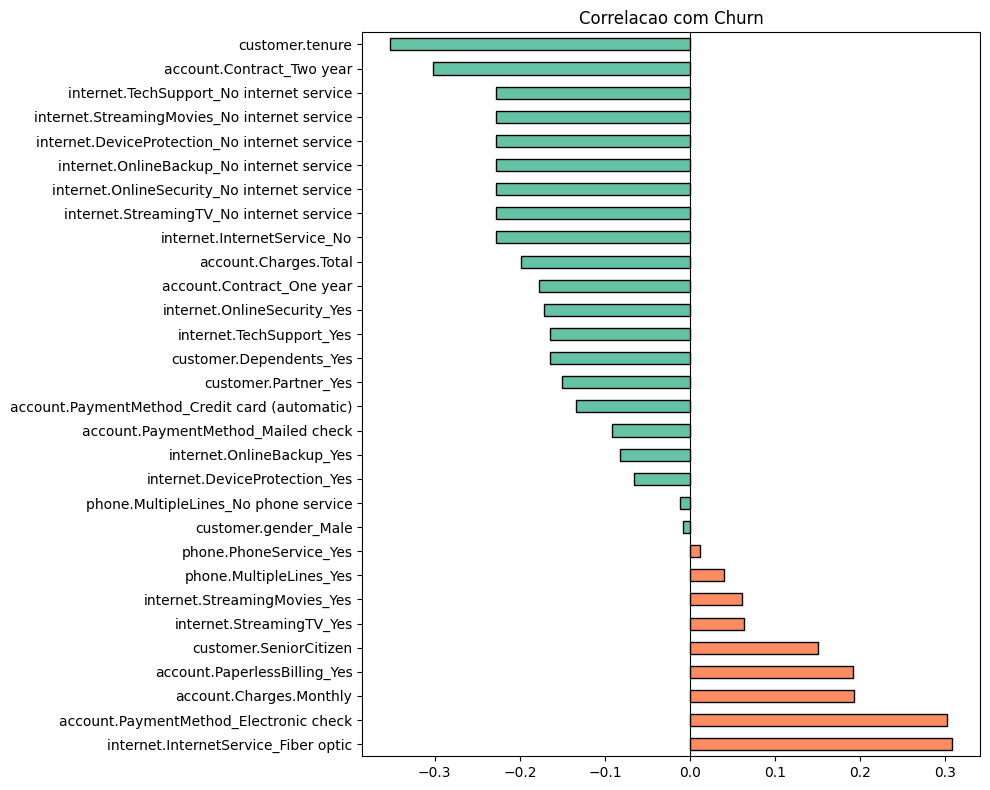

In [13]:
# grafico de correlacao com churn
fig, ax = plt.subplots(figsize=(10, 8))
cores = ['#fc8d62' if v > 0 else '#66c2a5' for v in corr_churn.values]
corr_churn.plot.barh(ax=ax, color=cores, edgecolor='black')
ax.set_title('Correlacao com Churn')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

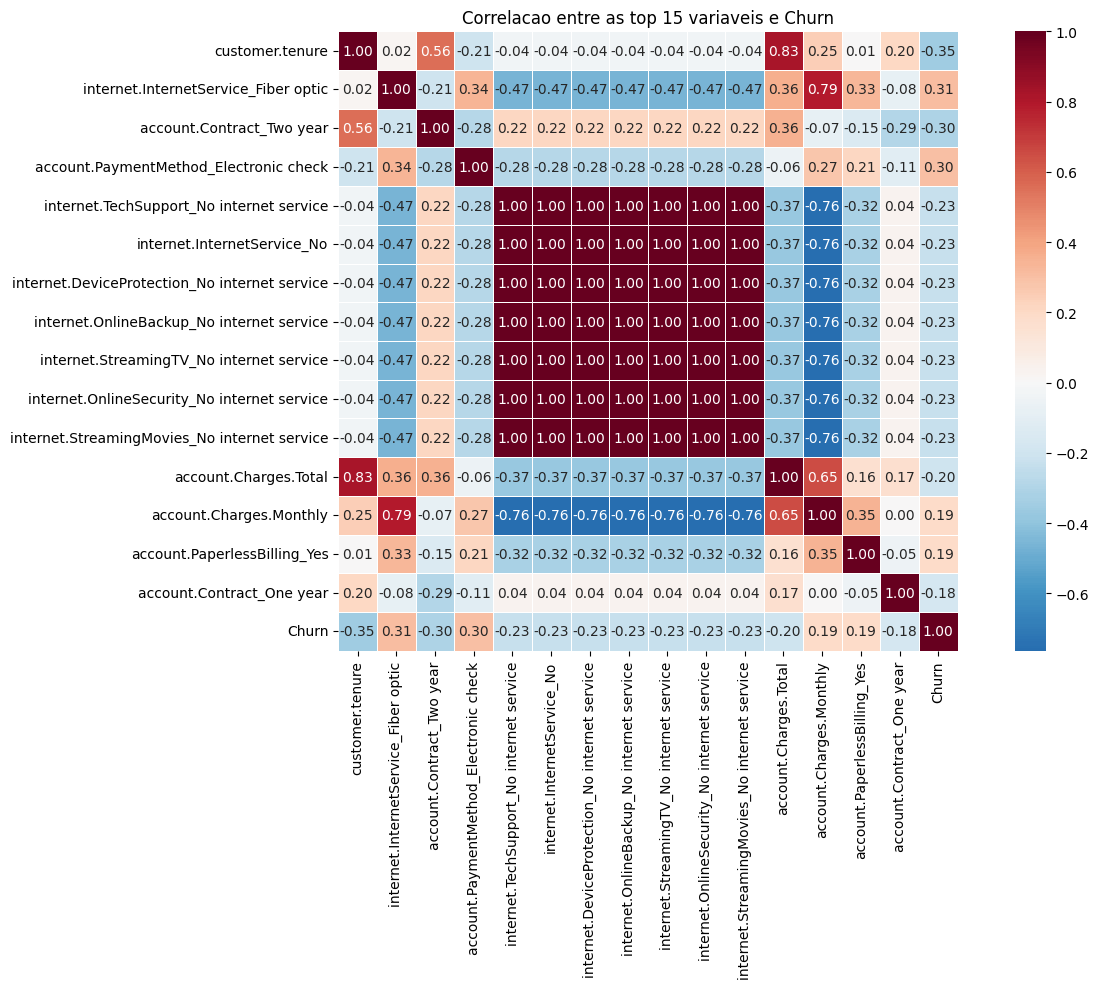

In [14]:
# heatmap com as top 15 variaveis
top_vars = corr_churn.abs().sort_values(ascending=False).head(15).index.tolist()
top_vars.append('Churn')

plt.figure(figsize=(14, 10))
sns.heatmap(tabela_encoded[top_vars].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Correlacao entre as top 15 variaveis e Churn')
plt.tight_layout()
plt.show()

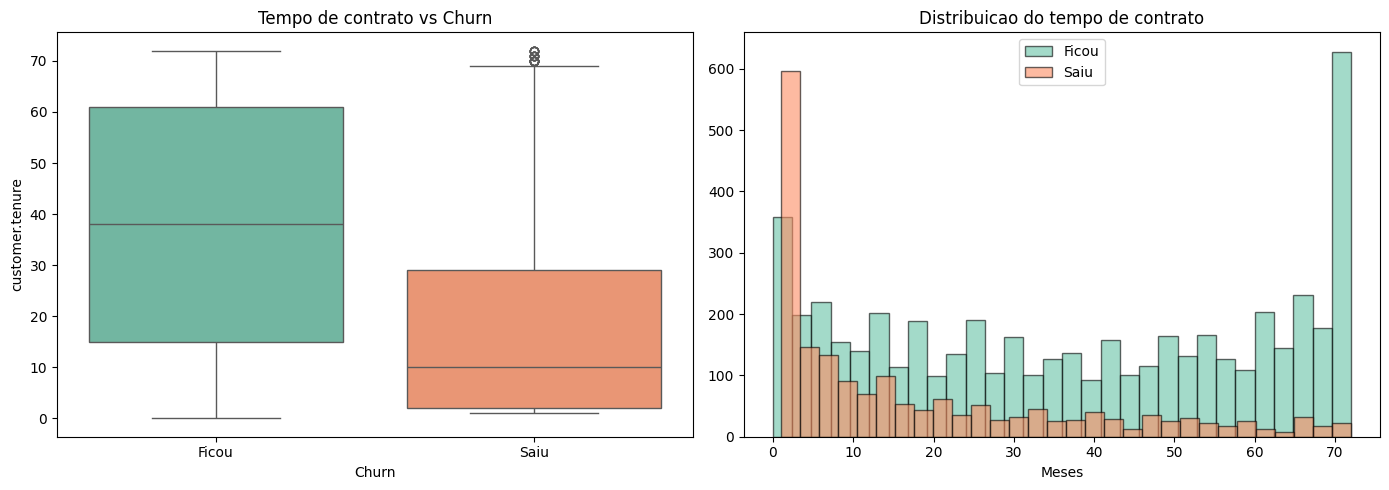

media de meses:
Churn
0    37.569965
1    17.979133
Name: customer.tenure, dtype: float64


In [15]:
# tenure vs churn
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Churn', y='customer.tenure', data=tabela_encoded, hue='Churn',
            palette=['#66c2a5', '#fc8d62'], ax=axs[0], legend=False)
axs[0].set_title('Tempo de contrato vs Churn')
axs[0].set_xticklabels(['Ficou', 'Saiu'])

for label, cor in zip([0, 1], ['#66c2a5', '#fc8d62']):
    subset = tabela_encoded[tabela_encoded['Churn'] == label]['customer.tenure']
    axs[1].hist(subset, bins=30, alpha=0.6, color=cor,
                label='Ficou' if label == 0 else 'Saiu', edgecolor='black')
axs[1].set_title('Distribuicao do tempo de contrato')
axs[1].set_xlabel('Meses')
axs[1].legend()

plt.tight_layout()
plt.show()

print("media de meses:")
print(tabela_encoded.groupby('Churn')['customer.tenure'].mean())

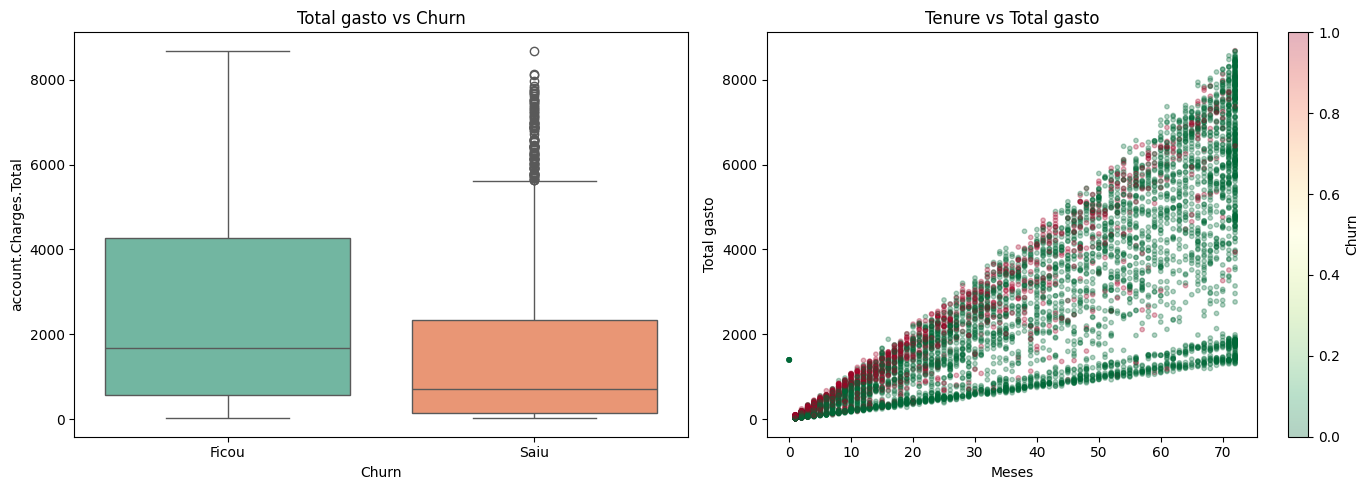

media gasto total:
Churn
0    2552.882494
1    1531.796094
Name: account.Charges.Total, dtype: float64


In [16]:
# total gasto vs churn
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Churn', y='account.Charges.Total', data=tabela_encoded, hue='Churn',
            palette=['#66c2a5', '#fc8d62'], ax=axs[0], legend=False)
axs[0].set_title('Total gasto vs Churn')
axs[0].set_xticklabels(['Ficou', 'Saiu'])

scatter = axs[1].scatter(tabela_encoded['customer.tenure'],
                          tabela_encoded['account.Charges.Total'],
                          c=tabela_encoded['Churn'],
                          cmap='RdYlGn_r', alpha=0.3, s=10)
axs[1].set_title('Tenure vs Total gasto')
axs[1].set_xlabel('Meses')
axs[1].set_ylabel('Total gasto')
plt.colorbar(scatter, ax=axs[1], label='Churn')

plt.tight_layout()
plt.show()

print("media gasto total:")
print(tabela_encoded.groupby('Churn')['account.Charges.Total'].mean())

#🤖 Modelagem Preditiva

In [17]:
# separando treino e teste 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"treino: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"teste:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)")

treino: 4930 (70%)
teste:  2113 (30%)


In [18]:
# normalizando os dados pra regressao logistica
# ela precisa disso porque é sensivel a escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# modelo 1 - regressao logistica (com normalizacao)
# escolhi esse porque é simples, da pra interpretar os coeficientes
# e funciona bem como baseline
modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Regressao Logistica:")
print(f"  acuracia: {acc_lr:.4f}")
print(f"  precisao: {prec_lr:.4f}")
print(f"  recall:   {rec_lr:.4f}")
print(f"  f1:       {f1_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Ficou', 'Saiu']))

Regressao Logistica:
  acuracia: 0.7354
  precisao: 0.5011
  recall:   0.8004
  f1:       0.6163

              precision    recall  f1-score   support

       Ficou       0.91      0.71      0.80      1552
        Saiu       0.50      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.70      0.76      0.71      2113
weighted avg       0.80      0.74      0.75      2113



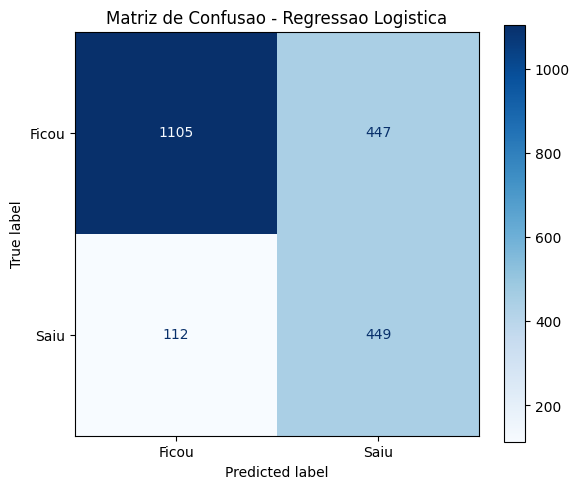

In [20]:
# matriz de confusao - regressao logistica
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Ficou', 'Saiu']).plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusao - Regressao Logistica')
plt.tight_layout()
plt.show()

In [21]:
# modelo 2 - random forest (sem normalizacao)
# escolhi esse porque nao precisa normalizar, funciona bem com variaveis
# categoricas e mostra a importancia de cada variavel
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest:")
print(f"  acuracia: {acc_rf:.4f}")
print(f"  precisao: {prec_rf:.4f}")
print(f"  recall:   {rec_rf:.4f}")
print(f"  f1:       {f1_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Ficou', 'Saiu']))

Random Forest:
  acuracia: 0.7719
  precisao: 0.5527
  recall:   0.7380
  f1:       0.6321

              precision    recall  f1-score   support

       Ficou       0.89      0.78      0.83      1552
        Saiu       0.55      0.74      0.63       561

    accuracy                           0.77      2113
   macro avg       0.72      0.76      0.73      2113
weighted avg       0.80      0.77      0.78      2113



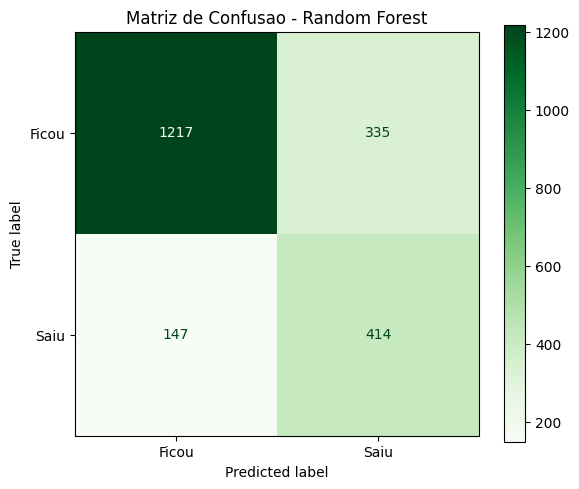

In [22]:
# matriz de confusao - random forest
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Ficou', 'Saiu']).plot(ax=ax, cmap='Greens')
ax.set_title('Matriz de Confusao - Random Forest')
plt.tight_layout()
plt.show()

 Metrica  Reg. Logistica  Random Forest
Acuracia        0.735447       0.771888
Precisao        0.501116       0.552737
  Recall        0.800357       0.737968
F1-Score        0.616335       0.632061


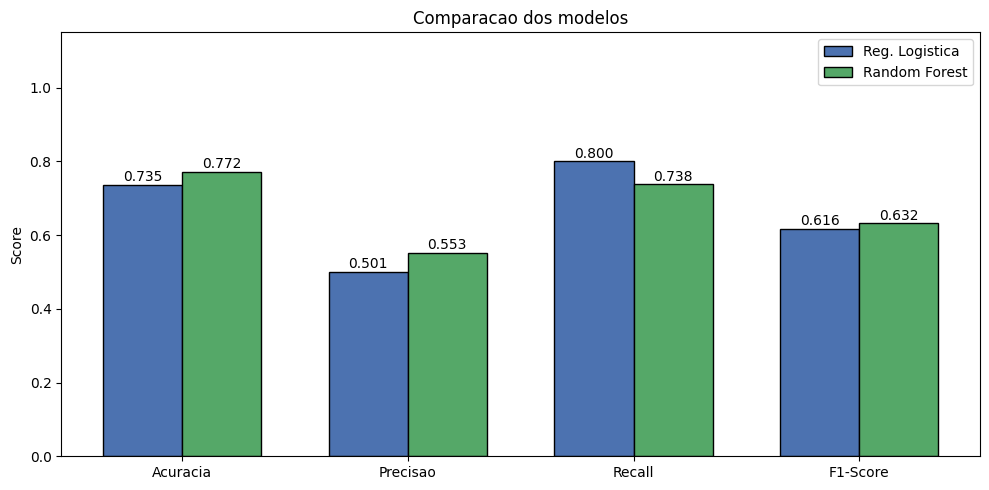

In [23]:
# comparando os dois modelos
comparacao = pd.DataFrame({
    'Metrica': ['Acuracia', 'Precisao', 'Recall', 'F1-Score'],
    'Reg. Logistica': [acc_lr, prec_lr, rec_lr, f1_lr],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf]
})
print(comparacao.to_string(index=False))

# grafico
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
largura = 0.35

b1 = ax.bar(x - largura/2, comparacao['Reg. Logistica'], largura,
            label='Reg. Logistica', color='#4C72B0', edgecolor='black')
b2 = ax.bar(x + largura/2, comparacao['Random Forest'], largura,
            label='Random Forest', color='#55A868', edgecolor='black')

for b in b1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{b.get_height():.3f}', ha='center', fontsize=10)
for b in b2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{b.get_height():.3f}', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(comparacao['Metrica'])
ax.set_ylabel('Score')
ax.set_title('Comparacao dos modelos')
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

In [24]:
# checando overfitting
acc_train_lr = modelo_lr.score(X_train_scaled, y_train)
acc_train_rf = modelo_rf.score(X_train, y_train)

print(f"Reg. Logistica -> treino: {acc_train_lr:.4f} | teste: {acc_lr:.4f} | diff: {abs(acc_train_lr - acc_lr):.4f}")
print(f"Random Forest  -> treino: {acc_train_rf:.4f} | teste: {acc_rf:.4f} | diff: {abs(acc_train_rf - acc_rf):.4f}")

# se a diferenca for grande (tipo >0.10) pode ser overfitting
# se a acuracia for baixa demais (<0.60) pode ser underfitting

Reg. Logistica -> treino: 0.7542 | teste: 0.7354 | diff: 0.0187
Random Forest  -> treino: 0.8444 | teste: 0.7719 | diff: 0.0725


#📋  Interpretação e Conclusões

variaveis que mais aumentam evasao:
                              Variavel  Coeficiente
                 account.Charges.Total     0.659596
  internet.InternetService_Fiber optic     0.633618
              internet.StreamingTV_Yes     0.205727
          internet.StreamingMovies_Yes     0.202064
          account.PaperlessBilling_Yes     0.197842
account.PaymentMethod_Electronic check     0.183823
               phone.MultipleLines_Yes     0.156888
                customer.SeniorCitizen     0.068304
         internet.DeviceProtection_Yes     0.025936
  phone.MultipleLines_No phone service     0.012475

variaveis que mais reduzem evasao:
                                     Variavel  Coeficiente
     internet.TechSupport_No internet service    -0.080660
internet.DeviceProtection_No internet service    -0.080660
 internet.StreamingMovies_No internet service    -0.080660
                  internet.OnlineSecurity_Yes    -0.084764
                      customer.Dependents_Yes    -0.098824
  

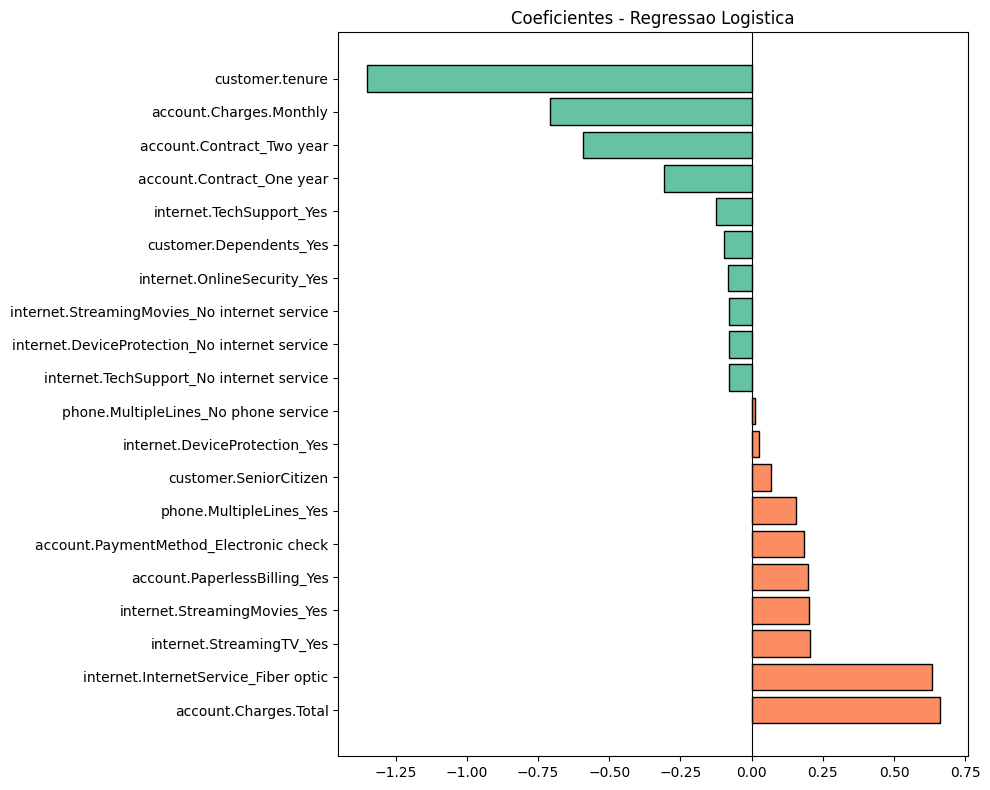

In [25]:
# coeficientes da regressao logistica
coefs = pd.DataFrame({
    'Variavel': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
}).sort_values('Coeficiente', ascending=False)

print("variaveis que mais aumentam evasao:")
print(coefs.head(10).to_string(index=False))
print("\nvariaveis que mais reduzem evasao:")
print(coefs.tail(10).to_string(index=False))

# grafico
fig, ax = plt.subplots(figsize=(10, 8))
top = pd.concat([coefs.head(10), coefs.tail(10)])
cores = ['#fc8d62' if c > 0 else '#66c2a5' for c in top['Coeficiente']]
ax.barh(top['Variavel'], top['Coeficiente'], color=cores, edgecolor='black')
ax.set_title('Coeficientes - Regressao Logistica')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

top 15 variaveis mais importantes:
                                     Variavel  Importancia
                              customer.tenure     0.177191
                        account.Charges.Total     0.146253
                    account.Contract_Two year     0.102754
                      account.Charges.Monthly     0.100293
         internet.InternetService_Fiber optic     0.060527
       account.PaymentMethod_Electronic check     0.053756
                    account.Contract_One year     0.047352
                  internet.OnlineSecurity_Yes     0.030237
                     internet.TechSupport_Yes     0.028657
internet.DeviceProtection_No internet service     0.021024
                 account.PaperlessBilling_Yes     0.019927
     internet.TechSupport_No internet service     0.016064
 internet.StreamingMovies_No internet service     0.015066
                      customer.Dependents_Yes     0.014900
  internet.OnlineSecurity_No internet service     0.014528


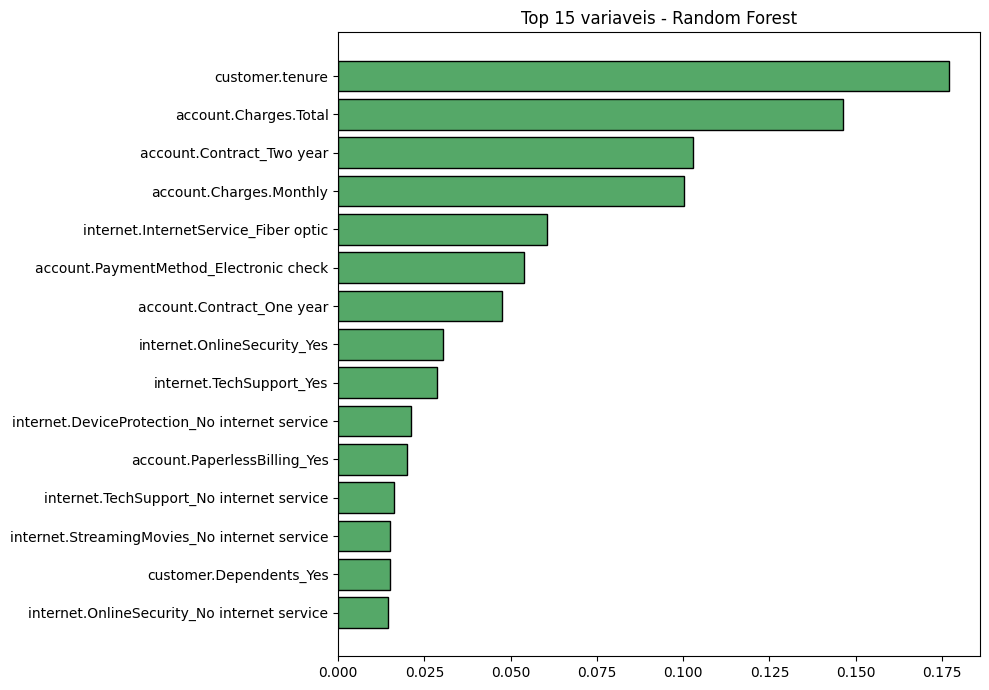

In [26]:
# importancia das variaveis - random forest
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print("top 15 variaveis mais importantes:")
print(importancias.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top15 = importancias.head(15).sort_values('Importancia')
ax.barh(top15['Variavel'], top15['Importancia'], color='#55A868', edgecolor='black')
ax.set_title('Top 15 variaveis - Random Forest')
plt.tight_layout()
plt.show()

In [27]:
# salvando
tabela_encoded.to_csv('TelecomX_processado.csv', index=False)
importancias.to_csv('TelecomX_importancia_variaveis.csv', index=False)

from google.colab import files
files.download('TelecomX_processado.csv')
files.download('TelecomX_importancia_variaveis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusão

Comparando os dois modelos, a regressão logística e o random forest tiveram
resultados parecidos, mas o recall é a metrica mais importante aqui porque
a gente quer pegar o maximo de clientes que vão sair (evitar falso negativo).

As variaveis que mais influenciam a evasão são:

- **Tipo de contrato**: clientes com contrato mensal saem muito mais do que
  quem tem contrato anual. Faz sentido porque tem menos compromisso.
- **Tempo como cliente**: quem ta a pouco tempo na empresa sai mais. Depois
  de uns meses a chance de sair diminui bastante.
- **Gasto mensal**: quem paga mais por mês tende a sair mais, talvez porque
  sente que nao ta valendo o preço.
- **Metodo de pagamento**: quem paga por boleto eletronico sai mais do que
  quem usa debito automatico.

Algumas ideias pra tentar reter esses clientes:
- Dar desconto pra quem migrar de contrato mensal pra anual
- Fazer um acompanhamento melhor nos primeiros meses do cliente
- Revisar os planos mais caros pra ver se o custo beneficio ta ok
- Incentivar pagamento por debito automatico